# NCES CCD Nonfiscal Data Analysis

## Purpose

The NCES Common Core of Data nonfiscal files provide district-level information about public school systems that is not financial.

For this project, three cleaned files are used:

- **District Directory** — district identity, location, and organizational characteristics
- **District Membership** — student enrollment
- **District Staff** — staffing levels and staff categories

Together, these data provide school-system capacity context for the pediatric mental health access analysis.

The primary goal is to examine how student enrollment and staffing resources vary across districts and states, with particular attention to student-facing staff capacity where available.

In [4]:
import pandas as pd
from pathlib import Path

cleaned_dir = Path("../../data/cleaned")

directory_path = cleaned_dir / "NCES_CCD_2024_25_District_Directory_clean.csv"
membership_path = cleaned_dir / "NCES_CCD_2024_25_District_Membership_clean.csv"
staff_path = cleaned_dir / "NCES_CCD_2024_25_District_Staff_clean.csv"

directory = pd.read_csv(directory_path)
membership = pd.read_csv(membership_path)
staff = pd.read_csv(staff_path)

print("Directory shape:", directory.shape)
print("Membership shape:", membership.shape)
print("Staff shape:", staff.shape)

Directory shape: (19630, 15)
Membership shape: (3822460, 15)
Staff shape: (454247, 13)


In [2]:
for f in cleaned_dir.glob("*NCES*2024*25*.csv"):
    print(f.name)

NCES_CCD_2024_25_District_Directory_clean.csv
NCES_CCD_2024_25_District_Membership_clean.csv
NCES_CCD_2024_25_District_Staff_clean.csv


## Dataset Structure

Before combining the three nonfiscal files, each dataset is inspected separately to identify the district identifier, enrollment measures, staffing measures, and geographic fields available for analysis.

The files will only be merged after confirming that the relevant district-level variables are present and compatible.

In [5]:
print("\nDIRECTORY COLUMNS")
for col in directory.columns:
    print(col)

print("\nMEMBERSHIP COLUMNS")
for col in membership.columns:
    print(col)

print("\nSTAFF COLUMNS")
for col in staff.columns:
    print(col)


DIRECTORY COLUMNS
SCHOOL_YEAR
LEAID
ST_LEAID
LEA_NAME
ST
STATENAME
FIPST
LCITY
LSTATE
LZIP
LEA_TYPE_TEXT
SY_STATUS_TEXT
UPDATED_STATUS_TEXT
LEVEL
OPERATIONAL_SCHOOLS

MEMBERSHIP COLUMNS
SCHOOL_YEAR
FIPST
STATENAME
ST
LEA_NAME
STATE_AGENCY_NO
UNION
ST_LEAID
LEAID
GRADE
RACE_ETHNICITY
SEX
STUDENT_COUNT
TOTAL_INDICATOR
DMS_FLAG

STAFF COLUMNS
SCHOOL_YEAR
FIPST
STATENAME
ST
LEA_NAME
STATE_AGENCY_NO
UNION
ST_LEAID
LEAID
STAFF
STAFF_COUNT
TOTAL_INDICATOR
DMS_FLAG


## District-Level Enrollment and Staffing Measures

The membership and staffing files are stored in long format, meaning each school district appears across multiple rows for different student groups or staff categories.

For this analysis, the data are reduced to district-level totals and selected staffing categories before being merged with the district directory.

This creates one analytical record per school district and avoids double-counting enrollment or staff.

In [6]:
staff_categories = (
    staff["STAFF"]
    .dropna()
    .value_counts()
)

staff_categories

STAFF
All Other Support Staff                                    19406
LEA Administrative Support Staff                           19406
LEA Administrators                                         19406
LEA Staff                                                  19406
Other Staff                                                19406
No Category Codes                                          19406
Guidance Counselors                                        18993
Teachers                                                   18993
School Staff                                               18975
School Administrative Support Staff                        18915
School administrators                                      18915
Instructional Coordinators and Supervisors to the Staff    18870
Librarians/media specialists                               18870
Library/Media Support Staff                                18870
Paraprofessionals/Instructional Aides                      18870
School Psychologist

In [7]:
print("Membership TOTAL_INDICATOR values:")
print(membership["TOTAL_INDICATOR"].value_counts(dropna=False))

print("\nStaff TOTAL_INDICATOR values:")
print(staff["TOTAL_INDICATOR"].value_counts(dropna=False))

Membership TOTAL_INDICATOR values:
TOTAL_INDICATOR
Category Set A - By Race/Ethnicity; Sex; Grade                              3271718
Derived - Subtotal by Race/Ethnicity and Sex minus Adult Education Count     278220
Subtotal 4 - By Grade                                                        235426
Derived - Education Unit Total minus Adult Education Count                    18548
Education Unit Total                                                          18548
Name: count, dtype: int64

Staff TOTAL_INDICATOR values:
TOTAL_INDICATOR
Category Set A                       339068
Derived - Major Staffing Category     95773
Education Unit Total                  19406
Name: count, dtype: int64


In [8]:
print("GRADE values:")
print(membership["GRADE"].value_counts(dropna=False))

print("\nRACE_ETHNICITY values:")
print(membership["RACE_ETHNICITY"].value_counts(dropna=False))

print("\nSEX values:")
print(membership["SEX"].value_counts(dropna=False))

GRADE values:
GRADE
No Category Codes    315316
Grade 6              263232
Grade 5              261168
Grade 1              260496
Grade 2              260368
Grade 4              260368
Grade 3              260192
Kindergarten         260048
Grade 8              259248
Grade 7              259104
Grade 9              225808
Grade 10             225600
Grade 11             225328
Grade 12             224928
Pre-Kindergarten     184544
Not Specified         37096
Ungraded              30048
Adult Education        6912
Grade 13               2656
Name: count, dtype: int64

RACE_ETHNICITY values:
RACE_ETHNICITY
American Indian or Alaska Native             470852
Asian                                        470852
Black or African American                    470852
Hispanic/Latino                              470852
Native Hawaiian or Other Pacific Islander    470852
Two or more races                            470852
White                                        470852
Not Specified      

## District Enrollment Totals

District enrollment is taken from membership records labeled `Education Unit Total`.

Using the district-level total avoids double-counting students across grade, race/ethnicity, and sex categories contained in the long-format membership file.

In [9]:
district_enrollment = (
    membership[
        membership["TOTAL_INDICATOR"] == "Education Unit Total"
    ][
        [
            "LEAID",
            "STATENAME",
            "ST",
            "LEA_NAME",
            "STUDENT_COUNT"
        ]
    ]
    .copy()
)

district_enrollment = district_enrollment.rename(
    columns={"STUDENT_COUNT": "TOTAL_ENROLLMENT"}
)

print("District enrollment rows:", len(district_enrollment))
print("Unique districts:", district_enrollment["LEAID"].nunique())

district_enrollment.head()

District enrollment rows: 18548
Unique districts: 18548


,LEAID,STATENAME,ST,LEA_NAME,TOTAL_ENROLLMENT
212,100002,ALABAMA,AL,Alabama Youth Services,NaN
454,100005,ALABAMA,AL,Albertville City,5910.0
697,100006,ALABAMA,AL,Marshall County,6494.0
940,100007,ALABAMA,AL,Hoover City,13632.0
1183,100008,ALABAMA,AL,Madison City,13046.0


## Student-Support Staffing

The staffing file contains several student-facing professional categories.

For this analysis, the initial focus is on:

- school psychologists
- school counselors
- guidance counselors
- student support services staff excluding psychologists

These categories are examined separately rather than summed together because some counselor categories may represent overlapping reporting structures.

In [10]:
support_staff_categories = [
    "School Psychologists",
    "School Counselors",
    "Guidance Counselors",
    "Student Support Services Staff (w/o Psychology)"
]

support_staff = staff[
    staff["STAFF"].isin(support_staff_categories)
][
    [
        "LEAID",
        "STATENAME",
        "ST",
        "LEA_NAME",
        "STAFF",
        "STAFF_COUNT"
    ]
].copy()

support_staff.head()

,LEAID,STATENAME,ST,LEA_NAME,STAFF,STAFF_COUNT
13,100002,ALABAMA,AL,Alabama Youth Services,School Counselors,NaN
14,100002,ALABAMA,AL,Alabama Youth Services,School Psychologists,NaN
17,100002,ALABAMA,AL,Alabama Youth Services,Student Support Services Staff (w/o Psychology),NaN
18,100002,ALABAMA,AL,Alabama Youth Services,Guidance Counselors,NaN
37,100005,ALABAMA,AL,Albertville City,School Counselors,0.0


In [11]:
support_staff_wide = (
    support_staff
    .pivot_table(
        index=["LEAID", "STATENAME", "ST", "LEA_NAME"],
        columns="STAFF",
        values="STAFF_COUNT",
        aggfunc="first"
    )
    .reset_index()
)

support_staff_wide.columns.name = None

support_staff_wide = support_staff_wide.rename(
    columns={
        "School Psychologists": "SCHOOL_PSYCHOLOGISTS",
        "School Counselors": "SCHOOL_COUNSELORS",
        "Guidance Counselors": "GUIDANCE_COUNSELORS",
        "Student Support Services Staff (w/o Psychology)": "STUDENT_SUPPORT_STAFF"
    }
)

print("Staff rows after pivot:", len(support_staff_wide))
support_staff_wide.head()

Staff rows after pivot: 18411


,LEAID,STATENAME,ST,LEA_NAME,GUIDANCE_COUNSELORS,SCHOOL_COUNSELORS,SCHOOL_PSYCHOLOGISTS,STUDENT_SUPPORT_STAFF
0,100005,ALABAMA,AL,Albertville City,14.0,0.0,0.0,6.00
1,100006,ALABAMA,AL,Marshall County,15.0,1.0,0.0,26.50
2,100007,ALABAMA,AL,Hoover City,36.0,0.0,0.0,52.00
3,100008,ALABAMA,AL,Madison City,28.5,0.0,1.0,62.17
4,100011,ALABAMA,AL,Leeds City,6.0,0.0,0.0,10.00


## District Staffing Capacity

Enrollment totals are merged with student-support staffing counts to create one record per district.

Staffing capacity is expressed as **students per staff member**. Higher ratios indicate that each professional is responsible for more students and therefore suggest lower staffing capacity.

The primary measures are:

- students per guidance counselor
- students per school psychologist
- students per student-support staff member

Staff categories are kept separate to avoid double-counting potentially overlapping counselor classifications.

In [12]:
district_staffing = (
    district_enrollment
    .merge(
        support_staff_wide[
            [
                "LEAID",
                "GUIDANCE_COUNSELORS",
                "SCHOOL_COUNSELORS",
                "SCHOOL_PSYCHOLOGISTS",
                "STUDENT_SUPPORT_STAFF"
            ]
        ],
        on="LEAID",
        how="left"
    )
)

print("Merged district rows:", len(district_staffing))
print("Unique districts:", district_staffing["LEAID"].nunique())

district_staffing.head()

Merged district rows: 18548
Unique districts: 18548


,LEAID,STATENAME,ST,LEA_NAME,TOTAL_ENROLLMENT,GUIDANCE_COUNSELORS,SCHOOL_COUNSELORS,SCHOOL_PSYCHOLOGISTS,STUDENT_SUPPORT_STAFF
0,100002,ALABAMA,AL,Alabama Youth Services,NaN,NaN,NaN,NaN,NaN
1,100005,ALABAMA,AL,Albertville City,5910.0,14.0,0.0,0.0,6.00
2,100006,ALABAMA,AL,Marshall County,6494.0,15.0,1.0,0.0,26.50
3,100007,ALABAMA,AL,Hoover City,13632.0,36.0,0.0,0.0,52.00
4,100008,ALABAMA,AL,Madison City,13046.0,28.5,0.0,1.0,62.17


In [13]:
staffing_cols = [
    "GUIDANCE_COUNSELORS",
    "SCHOOL_COUNSELORS",
    "SCHOOL_PSYCHOLOGISTS",
    "STUDENT_SUPPORT_STAFF"
]

staffing_check = pd.DataFrame({
    "Missing": district_staffing[staffing_cols].isna().sum(),
    "Zero": (district_staffing[staffing_cols] == 0).sum(),
    "Positive": (district_staffing[staffing_cols] > 0).sum()
})

staffing_check

,Missing,Zero,Positive
GUIDANCE_COUNSELORS,921,3874,13753
SCHOOL_COUNSELORS,6023,5444,7081
SCHOOL_PSYCHOLOGISTS,1293,8649,8606
STUDENT_SUPPORT_STAFF,1035,2632,14881


## Students per Student-Support Professional

Staff-to-student ratios are calculated only when a district reports a positive number of staff in that category.

Districts reporting zero staff are retained and flagged separately rather than assigning an artificial ratio, because division by zero would produce an undefined value.

Higher student-to-staff ratios represent lower staffing capacity.

In [14]:
import numpy as np

district_staffing["STUDENTS_PER_GUIDANCE_COUNSELOR"] = np.where(
    district_staffing["GUIDANCE_COUNSELORS"] > 0,
    district_staffing["TOTAL_ENROLLMENT"] /
    district_staffing["GUIDANCE_COUNSELORS"],
    np.nan
)

district_staffing["STUDENTS_PER_PSYCHOLOGIST"] = np.where(
    district_staffing["SCHOOL_PSYCHOLOGISTS"] > 0,
    district_staffing["TOTAL_ENROLLMENT"] /
    district_staffing["SCHOOL_PSYCHOLOGISTS"],
    np.nan
)

district_staffing["STUDENTS_PER_SUPPORT_STAFF"] = np.where(
    district_staffing["STUDENT_SUPPORT_STAFF"] > 0,
    district_staffing["TOTAL_ENROLLMENT"] /
    district_staffing["STUDENT_SUPPORT_STAFF"],
    np.nan
)

district_staffing[
    [
        "LEA_NAME",
        "STATENAME",
        "TOTAL_ENROLLMENT",
        "GUIDANCE_COUNSELORS",
        "STUDENTS_PER_GUIDANCE_COUNSELOR",
        "SCHOOL_PSYCHOLOGISTS",
        "STUDENTS_PER_PSYCHOLOGIST",
        "STUDENT_SUPPORT_STAFF",
        "STUDENTS_PER_SUPPORT_STAFF"
    ]
].head(10)

,LEA_NAME,STATENAME,TOTAL_ENROLLMENT,GUIDANCE_COUNSELORS,STUDENTS_PER_GUIDANCE_COUNSELOR,SCHOOL_PSYCHOLOGISTS,STUDENTS_PER_PSYCHOLOGIST,STUDENT_SUPPORT_STAFF,STUDENTS_PER_SUPPORT_STAFF
0,Alabama Youth Services,ALABAMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albertville City,ALABAMA,5910.0,14.0,422.142857,0.0,NaN,6.00,985.000000
2,Marshall County,ALABAMA,6494.0,15.0,432.933333,0.0,NaN,26.50,245.056604
3,Hoover City,ALABAMA,13632.0,36.0,378.666667,0.0,NaN,52.00,262.153846
4,Madison City,ALABAMA,13046.0,28.5,457.754386,1.0,13046.0,62.17,209.843976
5,Al Inst Deaf And Blind,ALABAMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Al Sch Of Math And Science,ALABAMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Leeds City,ALABAMA,2271.0,6.0,378.500000,0.0,NaN,10.00,227.100000
8,Boaz City,ALABAMA,2607.0,6.0,434.500000,0.0,NaN,5.10,511.176471
9,Trussville City,ALABAMA,5005.0,11.5,435.217391,2.0,2502.5,17.98,278.364850


In [15]:
ratio_cols = [
    "STUDENTS_PER_GUIDANCE_COUNSELOR",
    "STUDENTS_PER_PSYCHOLOGIST",
    "STUDENTS_PER_SUPPORT_STAFF"
]

district_staffing[ratio_cols].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
STUDENTS_PER_GUIDANCE_COUNSELOR,13748.0,479.4,2107.1,0.0,245.0,331.7,452.1,159500.0
STUDENTS_PER_PSYCHOLOGIST,8604.0,1325.3,2998.2,0.0,522.0,833.2,1359.9,117100.0
STUDENTS_PER_SUPPORT_STAFF,14871.0,263.6,697.8,0.0,72.2,132.0,252.1,30100.0


## Staffing Availability and Capacity

Student-support staffing varies substantially across school districts.

A large number of districts report no staff in specific support categories. School psychologists show the greatest gap: 8,649 districts report zero school psychologists, compared with 3,874 districts reporting zero guidance counselors and 2,632 reporting zero broader student-support staff.

Among districts reporting positive staffing and enrollment, the median staffing ratios are approximately:

- 332 students per guidance counselor
- 833 students per school psychologist
- 132 students per broader student-support staff member

Because staffing ratios contain extreme outliers, subsequent comparisons emphasize medians rather than means.

In [16]:
# Keep districts with positive enrollment for staffing ratio comparisons

staffing_analysis = district_staffing[
    district_staffing["TOTAL_ENROLLMENT"] > 0
].copy()

ratio_cols = [
    "STUDENTS_PER_GUIDANCE_COUNSELOR",
    "STUDENTS_PER_PSYCHOLOGIST",
    "STUDENTS_PER_SUPPORT_STAFF"
]

print("Districts with positive enrollment:", len(staffing_analysis))

staffing_analysis[ratio_cols].describe().T.round(1)

Districts with positive enrollment: 18014


,count,mean,std,min,25%,50%,75%,max
STUDENTS_PER_GUIDANCE_COUNSELOR,13634.0,483.4,2115.4,0.5,247.4,333.0,454.0,159500.0
STUDENTS_PER_PSYCHOLOGIST,8478.0,1345.0,3016.0,2.0,533.7,843.1,1376.0,117100.0
STUDENTS_PER_SUPPORT_STAFF,14641.0,267.8,702.4,0.3,74.5,134.0,255.5,30100.0


## State-Level Student-Support Capacity

District staffing measures are summarized at the state level using median student-to-staff ratios.

Higher student-to-staff ratios indicate lower staffing capacity because each professional is responsible for more students.

The analysis also considers the percentage of districts reporting zero professionals in each category. This distinguishes states where existing staff carry large caseloads from states where many districts report no staff in that category at all.

In [17]:
# Exclude DC for formal 50-state comparisons

staffing_50 = staffing_analysis[
    staffing_analysis["STATENAME"].str.upper() != "DISTRICT OF COLUMBIA"
].copy()

state_staffing = (
    staffing_50
    .groupby("STATENAME")
    .agg(
        DISTRICTS=("LEAID", "nunique"),

        MEDIAN_STUDENTS_PER_COUNSELOR=(
            "STUDENTS_PER_GUIDANCE_COUNSELOR", "median"
        ),

        MEDIAN_STUDENTS_PER_PSYCHOLOGIST=(
            "STUDENTS_PER_PSYCHOLOGIST", "median"
        ),

        MEDIAN_STUDENTS_PER_SUPPORT_STAFF=(
            "STUDENTS_PER_SUPPORT_STAFF", "median"
        ),

        ZERO_COUNSELOR_DISTRICTS=(
            "GUIDANCE_COUNSELORS",
            lambda x: (x == 0).sum()
        ),

        ZERO_PSYCHOLOGIST_DISTRICTS=(
            "SCHOOL_PSYCHOLOGISTS",
            lambda x: (x == 0).sum()
        ),

        ZERO_SUPPORT_STAFF_DISTRICTS=(
            "STUDENT_SUPPORT_STAFF",
            lambda x: (x == 0).sum()
        )
    )
    .reset_index()
)

state_staffing["PCT_ZERO_COUNSELOR"] = (
    state_staffing["ZERO_COUNSELOR_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

state_staffing["PCT_ZERO_PSYCHOLOGIST"] = (
    state_staffing["ZERO_PSYCHOLOGIST_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

state_staffing["PCT_ZERO_SUPPORT_STAFF"] = (
    state_staffing["ZERO_SUPPORT_STAFF_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

state_staffing.round(1).head()

,STATENAME,DISTRICTS,MEDIAN_STUDENTS_PER_COUNSELOR,MEDIAN_STUDENTS_PER_PSYCHOLOGIST,MEDIAN_STUDENTS_PER_SUPPORT_STAFF,ZERO_COUNSELOR_DISTRICTS,ZERO_PSYCHOLOGIST_DISTRICTS,ZERO_SUPPORT_STAFF_DISTRICTS,PCT_ZERO_COUNSELOR,PCT_ZERO_PSYCHOLOGIST,PCT_ZERO_SUPPORT_STAFF
0,ALABAMA,153,383.5,4492.5,274.0,4,147,4,2.6,96.1,2.6
1,ALASKA,53,336.0,1080.0,216.1,20,42,27,37.7,79.2,50.9
2,ARIZONA,659,418.6,712.0,78.4,382,492,237,58.0,74.7,36.0
3,ARKANSAS,263,335.8,1775.0,66.0,9,218,2,3.4,82.9,0.8
4,BUREAU OF INDIAN EDUCATION,174,139.0,216.2,66.2,0,0,0,0.0,0.0,0.0


In [18]:
psychologist_capacity = (
    state_staffing
    .dropna(subset=["MEDIAN_STUDENTS_PER_PSYCHOLOGIST"])
    .sort_values(
        "MEDIAN_STUDENTS_PER_PSYCHOLOGIST",
        ascending=False
    )
)

psychologist_capacity[
    [
        "STATENAME",
        "DISTRICTS",
        "MEDIAN_STUDENTS_PER_PSYCHOLOGIST",
        "PCT_ZERO_PSYCHOLOGIST"
    ]
].head(15).round(1)

,STATENAME,DISTRICTS,MEDIAN_STUDENTS_PER_PSYCHOLOGIST,PCT_ZERO_PSYCHOLOGIST
36,NORTHERN MARIANAS,1,8965.0,0.0
11,GUAM,5,4682.6,0.0
0,ALABAMA,153,4492.5,96.1
25,MISSISSIPPI,152,3289.5,9.9
47,U.S. VIRGIN ISLANDS,2,2572.5,50.0
48,UTAH,155,2195.0,77.4
9,FLORIDA,82,2079.8,32.9
16,IOWA,329,1913.9,99.1
38,OKLAHOMA,542,1898.0,88.7
10,GEORGIA,234,1870.1,29.9


In [21]:
# Keep only the 50 U.S. states

states_50 = [
    "ALABAMA", "ALASKA", "ARIZONA", "ARKANSAS", "CALIFORNIA",
    "COLORADO", "CONNECTICUT", "DELAWARE", "FLORIDA", "GEORGIA",
    "HAWAII", "IDAHO", "ILLINOIS", "INDIANA", "IOWA",
    "KANSAS", "KENTUCKY", "LOUISIANA", "MAINE", "MARYLAND",
    "MASSACHUSETTS", "MICHIGAN", "MINNESOTA", "MISSISSIPPI", "MISSOURI",
    "MONTANA", "NEBRASKA", "NEVADA", "NEW HAMPSHIRE", "NEW JERSEY",
    "NEW MEXICO", "NEW YORK", "NORTH CAROLINA", "NORTH DAKOTA", "OHIO",
    "OKLAHOMA", "OREGON", "PENNSYLVANIA", "RHODE ISLAND", "SOUTH CAROLINA",
    "SOUTH DAKOTA", "TENNESSEE", "TEXAS", "UTAH", "VERMONT",
    "VIRGINIA", "WASHINGTON", "WEST VIRGINIA", "WISCONSIN", "WYOMING"
]

staffing_50 = staffing_analysis[
    staffing_analysis["STATENAME"].str.upper().isin(states_50)
].copy()

print("States included:", staffing_50["STATENAME"].nunique())
print(sorted(staffing_50["STATENAME"].unique()))

States included: 50
['ALABAMA', 'ALASKA', 'ARIZONA', 'ARKANSAS', 'CALIFORNIA', 'COLORADO', 'CONNECTICUT', 'DELAWARE', 'FLORIDA', 'GEORGIA', 'HAWAII', 'IDAHO', 'ILLINOIS', 'INDIANA', 'IOWA', 'KANSAS', 'KENTUCKY', 'LOUISIANA', 'MAINE', 'MARYLAND', 'MASSACHUSETTS', 'MICHIGAN', 'MINNESOTA', 'MISSISSIPPI', 'MISSOURI', 'MONTANA', 'NEBRASKA', 'NEVADA', 'NEW HAMPSHIRE', 'NEW JERSEY', 'NEW MEXICO', 'NEW YORK', 'NORTH CAROLINA', 'NORTH DAKOTA', 'OHIO', 'OKLAHOMA', 'OREGON', 'PENNSYLVANIA', 'RHODE ISLAND', 'SOUTH CAROLINA', 'SOUTH DAKOTA', 'TENNESSEE', 'TEXAS', 'UTAH', 'VERMONT', 'VIRGINIA', 'WASHINGTON', 'WEST VIRGINIA', 'WISCONSIN', 'WYOMING']


In [31]:
state_staffing = (
    staffing_50
    .groupby("STATENAME")
    .agg(
        DISTRICTS=("LEAID", "nunique"),

        MEDIAN_STUDENTS_PER_COUNSELOR=(
            "STUDENTS_PER_GUIDANCE_COUNSELOR", "median"
        ),

        MEDIAN_STUDENTS_PER_PSYCHOLOGIST=(
            "STUDENTS_PER_PSYCHOLOGIST", "median"
        ),

        MEDIAN_STUDENTS_PER_SUPPORT_STAFF=(
            "STUDENTS_PER_SUPPORT_STAFF", "median"
        ),

        ZERO_COUNSELOR_DISTRICTS=(
            "GUIDANCE_COUNSELORS",
            lambda x: (x == 0).sum()
        ),

        ZERO_PSYCHOLOGIST_DISTRICTS=(
            "SCHOOL_PSYCHOLOGISTS",
            lambda x: (x == 0).sum()
        ),

        ZERO_SUPPORT_STAFF_DISTRICTS=(
            "STUDENT_SUPPORT_STAFF",
            lambda x: (x == 0).sum()
        )
    )
    .reset_index()
)

state_staffing["PCT_ZERO_COUNSELOR"] = (
    state_staffing["ZERO_COUNSELOR_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

state_staffing["PCT_ZERO_PSYCHOLOGIST"] = (
    state_staffing["ZERO_PSYCHOLOGIST_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

state_staffing["PCT_ZERO_SUPPORT_STAFF"] = (
    state_staffing["ZERO_SUPPORT_STAFF_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

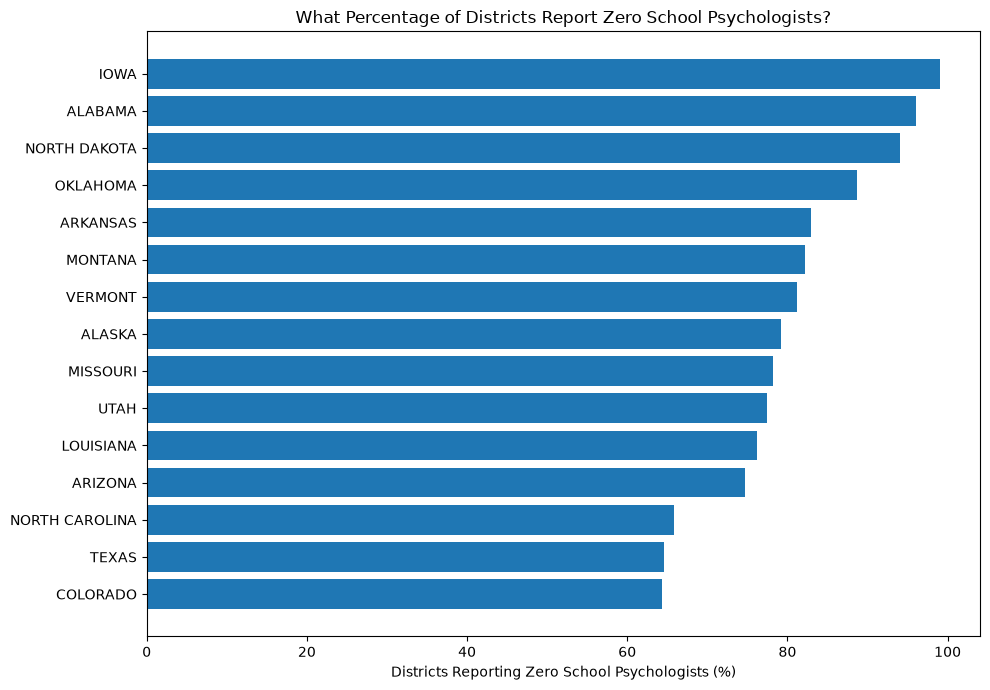

In [33]:
zero_psychologist_states = (
    state_staffing
    .sort_values("PCT_ZERO_PSYCHOLOGIST", ascending=False)
    .head(15)
    .sort_values("PCT_ZERO_PSYCHOLOGIST")
)

plt.figure(figsize=(10, 7))

plt.barh(
    zero_psychologist_states["STATENAME"],
    zero_psychologist_states["PCT_ZERO_PSYCHOLOGIST"]
)

plt.xlabel("Districts Reporting Zero School Psychologists (%)")
plt.ylabel("")
plt.title(
    "What Percentage of Districts Report Zero School Psychologists?"
)

plt.tight_layout()
plt.show()

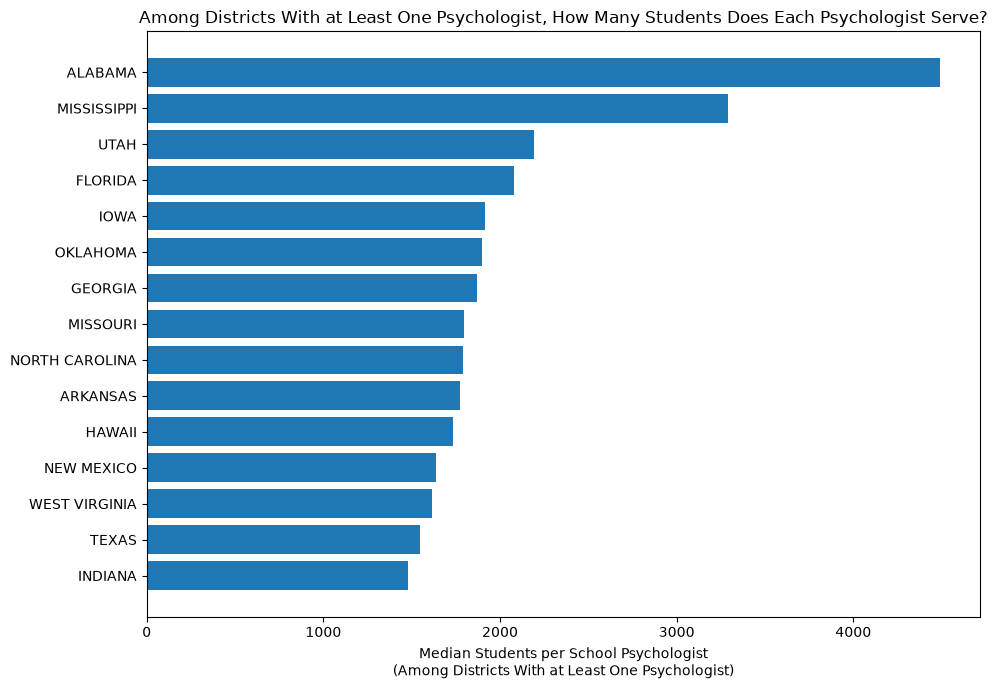

In [34]:
psychologist_capacity = (
    state_staffing
    .dropna(subset=["MEDIAN_STUDENTS_PER_PSYCHOLOGIST"])
    .sort_values(
        "MEDIAN_STUDENTS_PER_PSYCHOLOGIST",
        ascending=False
    )
)

top_psychologist_ratios = (
    psychologist_capacity
    .head(15)
    .sort_values("MEDIAN_STUDENTS_PER_PSYCHOLOGIST")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_psychologist_ratios["STATENAME"],
    top_psychologist_ratios["MEDIAN_STUDENTS_PER_PSYCHOLOGIST"]
)

plt.xlabel(
    "Median Students per School Psychologist\n"
    "(Among Districts With at Least One Psychologist)"
)
plt.ylabel("")
plt.title(
    "Among Districts With at Least One Psychologist, "
    "How Many Students Does Each Psychologist Serve?"
)

plt.tight_layout()
plt.show()

## School Psychologist Availability and Capacity

The two school psychologist charts measure **different aspects of staffing access and should not be interpreted as the same measure**.

### Districts Reporting Zero School Psychologists

The first chart shows the **percentage of school districts in each state that report zero school psychologists**.

A higher percentage means school psychologist availability is more limited across districts.

For example:

- **Iowa:** nearly 100% of districts report zero school psychologists.
- **Alabama:** approximately 96% of districts report zero school psychologists.
- **Louisiana:** approximately 76% of districts report zero school psychologists.
- **Texas:** approximately 65% of districts report zero school psychologists.

This measure answers:

**How often does a district report having no school psychologist at all?**

### Students per Psychologist Among Districts With At Least One

The second chart includes **only districts that report at least one school psychologist**.

It shows the median number of students served per psychologist within those staffed districts. A higher ratio means each psychologist is responsible for more students, indicating lower staffing capacity.

For example:

- **Alabama:** approximately 4,500 students per psychologist.
- **Mississippi:** approximately 3,300 students per psychologist.
- **Iowa:** approximately 1,900 students per psychologist.
- **Texas:** approximately 1,500 students per psychologist.

This measure answers:

**When a district does have a school psychologist, how many students does each psychologist serve?**

### Interpretation

These measures capture two different staffing problems:

- **Availability:** whether districts report having a school psychologist at all.
- **Capacity:** how many students each psychologist serves in districts where psychologists are present.

A state can therefore perform poorly on one or both measures.

For example, Iowa has an especially large **availability gap**, with nearly all districts reporting zero psychologists. Among the relatively small number of Iowa districts that do report at least one psychologist, the median psychologist serves roughly 1,900 students.

Alabama shows both an **availability and capacity problem**: most districts report zero psychologists, and psychologists in districts where they are present serve particularly large student populations.

These findings should not be interpreted as saying that every student in a state has the stated student-to-psychologist ratio. The ratio applies only to districts reporting at least one school psychologist.

## Guidance Counselor Capacity

Guidance counselor staffing is analyzed separately from school psychologist staffing.

Two measures are used:

- the percentage of districts reporting zero guidance counselors
- the median number of students per guidance counselor among districts reporting at least one guidance counselor

Together, these measures distinguish between counselor availability and counselor workload.

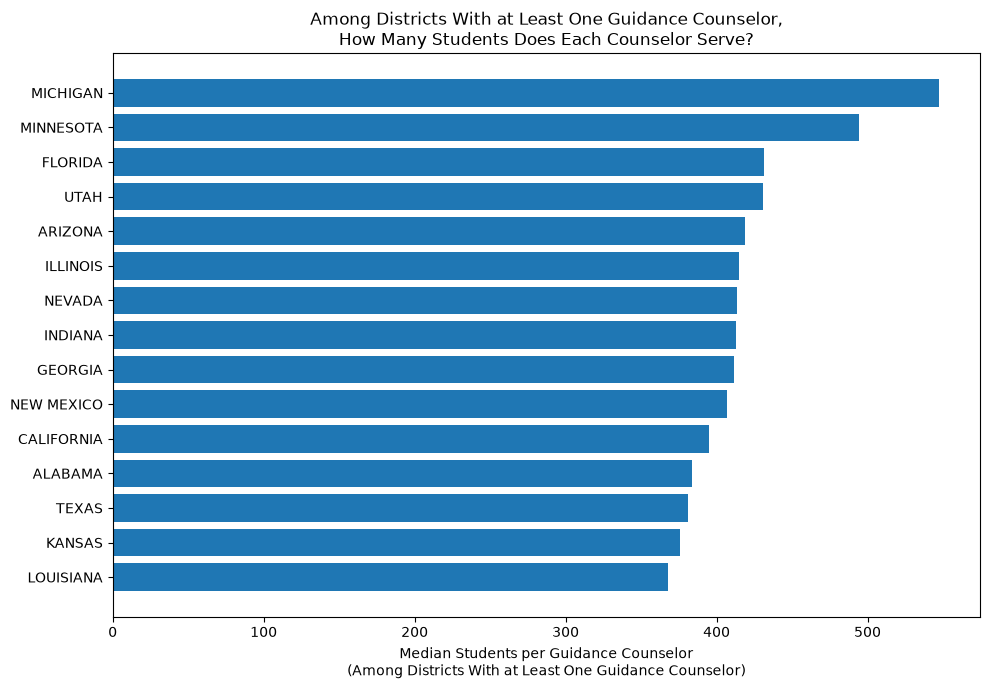

In [40]:
# States with the highest median students per guidance counselor

counselor_capacity = (
    state_staffing
    .dropna(subset=["MEDIAN_STUDENTS_PER_COUNSELOR"])
    .sort_values(
        "MEDIAN_STUDENTS_PER_COUNSELOR",
        ascending=False
    )
)

top_counselor_ratios = (
    counselor_capacity
    .head(15)
    .sort_values("MEDIAN_STUDENTS_PER_COUNSELOR")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_counselor_ratios["STATENAME"],
    top_counselor_ratios["MEDIAN_STUDENTS_PER_COUNSELOR"]
)

plt.xlabel(
    "Median Students per Guidance Counselor\n"
    "(Among Districts With at Least One Guidance Counselor)"
)

plt.ylabel("")

plt.title(
    "Among Districts With at Least One Guidance Counselor,\n"
    "How Many Students Does Each Counselor Serve?"
)

plt.tight_layout()
plt.show()

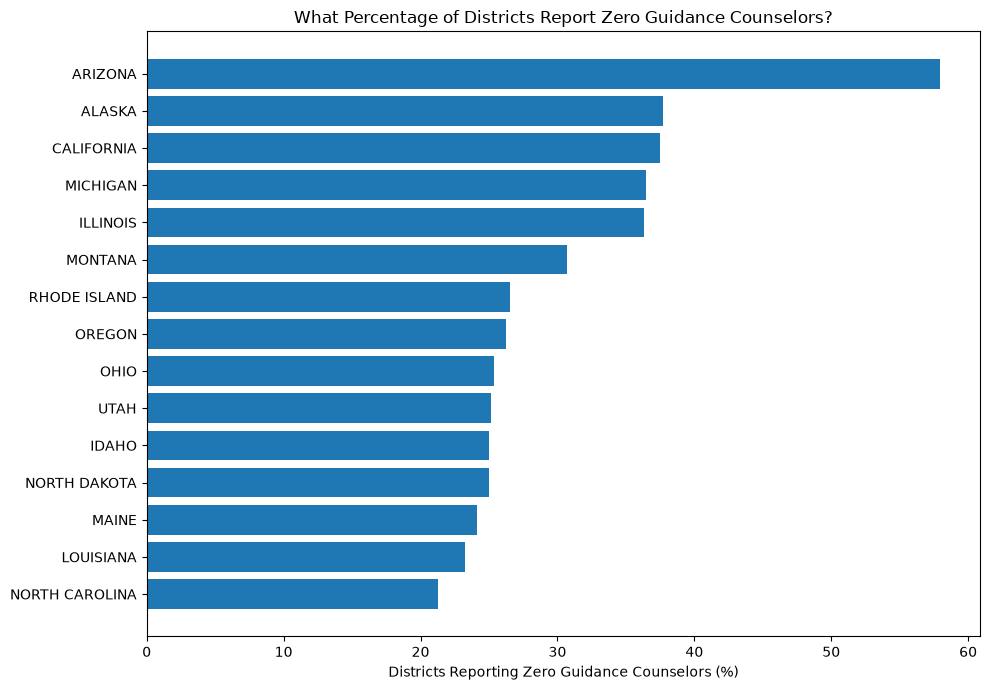

In [36]:
zero_counselor_states = (
    state_staffing
    .sort_values("PCT_ZERO_COUNSELOR", ascending=False)
    .head(15)
    .sort_values("PCT_ZERO_COUNSELOR")
)

plt.figure(figsize=(10, 7))

plt.barh(
    zero_counselor_states["STATENAME"],
    zero_counselor_states["PCT_ZERO_COUNSELOR"]
)

plt.xlabel("Districts Reporting Zero Guidance Counselors (%)")
plt.ylabel("")
plt.title(
    "What Percentage of Districts Report Zero Guidance Counselors?"
)

plt.tight_layout()
plt.show()

## Broader Student-Support Staffing

The NCES staffing data also identify student support services staff excluding psychologists.

This category provides a broader measure of student-facing support capacity beyond school psychologists and guidance counselors.

As with the other staffing categories, the analysis examines both availability and workload.

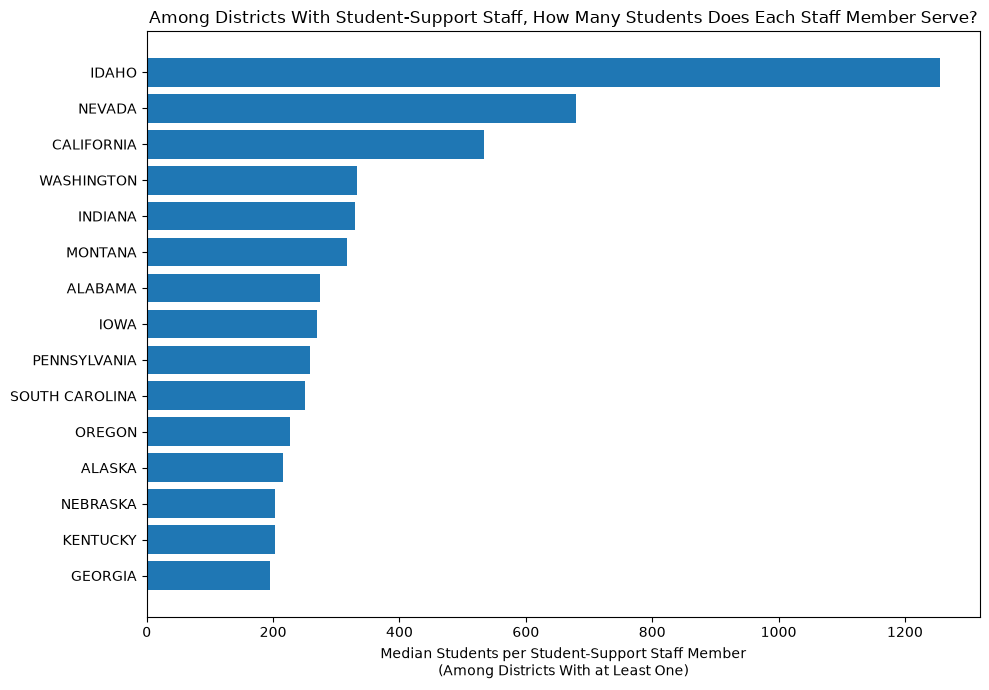

In [37]:
support_capacity = (
    state_staffing
    .dropna(subset=["MEDIAN_STUDENTS_PER_SUPPORT_STAFF"])
    .sort_values(
        "MEDIAN_STUDENTS_PER_SUPPORT_STAFF",
        ascending=False
    )
)

top_support_ratios = (
    support_capacity
    .head(15)
    .sort_values("MEDIAN_STUDENTS_PER_SUPPORT_STAFF")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_support_ratios["STATENAME"],
    top_support_ratios["MEDIAN_STUDENTS_PER_SUPPORT_STAFF"]
)

plt.xlabel(
    "Median Students per Student-Support Staff Member\n"
    "(Among Districts With at Least One)"
)
plt.ylabel("")
plt.title(
    "Among Districts With Student-Support Staff, "
    "How Many Students Does Each Staff Member Serve?"
)

plt.tight_layout()
plt.show()

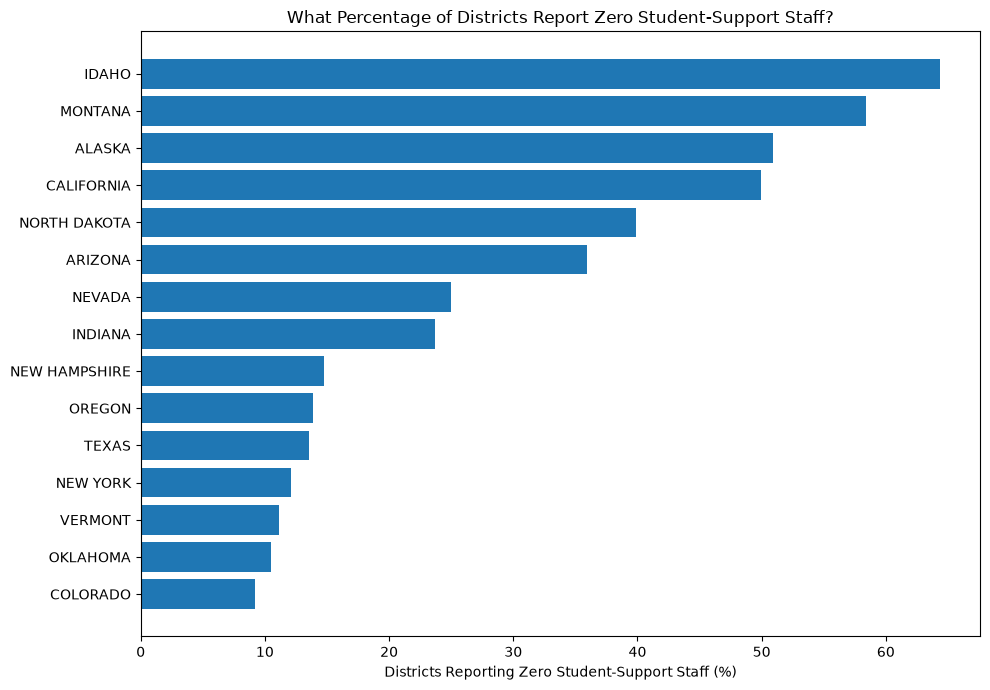

In [38]:
zero_support_states = (
    state_staffing
    .sort_values("PCT_ZERO_SUPPORT_STAFF", ascending=False)
    .head(15)
    .sort_values("PCT_ZERO_SUPPORT_STAFF")
)

plt.figure(figsize=(10, 7))

plt.barh(
    zero_support_states["STATENAME"],
    zero_support_states["PCT_ZERO_SUPPORT_STAFF"]
)

plt.xlabel("Districts Reporting Zero Student-Support Staff (%)")
plt.ylabel("")
plt.title(
    "What Percentage of Districts Report Zero Student-Support Staff?"
)

plt.tight_layout()
plt.show()

## Teacher Staffing Capacity

Teacher staffing provides broader school-system capacity context.

Unlike psychologists, counselors, and student-support staff, teachers are not a mental-health-specific resource. However, student-to-teacher ratios provide a useful comparison for understanding whether support-staff shortages occur within generally low-staffed school systems or are more specific to student-support roles.

In [39]:
teachers = (
    staff[
        staff["STAFF"] == "Teachers"
    ][
        ["LEAID", "STAFF_COUNT"]
    ]
    .rename(columns={"STAFF_COUNT": "TEACHERS"})
    .copy()
)

district_staffing = district_staffing.merge(
    teachers,
    on="LEAID",
    how="left"
)

district_staffing["STUDENTS_PER_TEACHER"] = np.where(
    (district_staffing["TEACHERS"] > 0) &
    (district_staffing["TOTAL_ENROLLMENT"] > 0),
    district_staffing["TOTAL_ENROLLMENT"] /
    district_staffing["TEACHERS"],
    np.nan
)

district_staffing[
    [
        "LEA_NAME",
        "STATENAME",
        "TOTAL_ENROLLMENT",
        "TEACHERS",
        "STUDENTS_PER_TEACHER"
    ]
].head()

,LEA_NAME,STATENAME,TOTAL_ENROLLMENT,TEACHERS,STUDENTS_PER_TEACHER
0,Alabama Youth Services,ALABAMA,NaN,NaN,NaN
1,Albertville City,ALABAMA,5910.0,321.50,18.382582
2,Marshall County,ALABAMA,6494.0,343.98,18.879005
3,Hoover City,ALABAMA,13632.0,939.20,14.514480
4,Madison City,ALABAMA,13046.0,774.60,16.842241


## Combined Student-Support Staffing Availability

To examine overall student-support staffing availability, each district is classified according to how many of three support categories are present:

- guidance counselors
- school psychologists
- broader student-support services staff

Each district receives a count from 0 to 3:

- **0:** none of the three staffing categories are present
- **1:** one staffing category is present
- **2:** two staffing categories are present
- **3:** all three staffing categories are present

This measure summarizes the breadth of student-support staffing available within each district. It does not measure staffing quality or workload.

In [41]:
# Count how many of the three support categories are present in each district

staffing_50["HAS_GUIDANCE_COUNSELOR"] = (
    staffing_50["GUIDANCE_COUNSELORS"] > 0
).astype(int)

staffing_50["HAS_PSYCHOLOGIST"] = (
    staffing_50["SCHOOL_PSYCHOLOGISTS"] > 0
).astype(int)

staffing_50["HAS_SUPPORT_STAFF"] = (
    staffing_50["STUDENT_SUPPORT_STAFF"] > 0
).astype(int)

staffing_50["SUPPORT_TYPES_PRESENT"] = (
    staffing_50["HAS_GUIDANCE_COUNSELOR"]
    + staffing_50["HAS_PSYCHOLOGIST"]
    + staffing_50["HAS_SUPPORT_STAFF"]
)

staffing_50["SUPPORT_TYPES_PRESENT"].value_counts().sort_index()

SUPPORT_TYPES_PRESENT
0    1836
1    2720
2    5997
3    7207
Name: count, dtype: int64

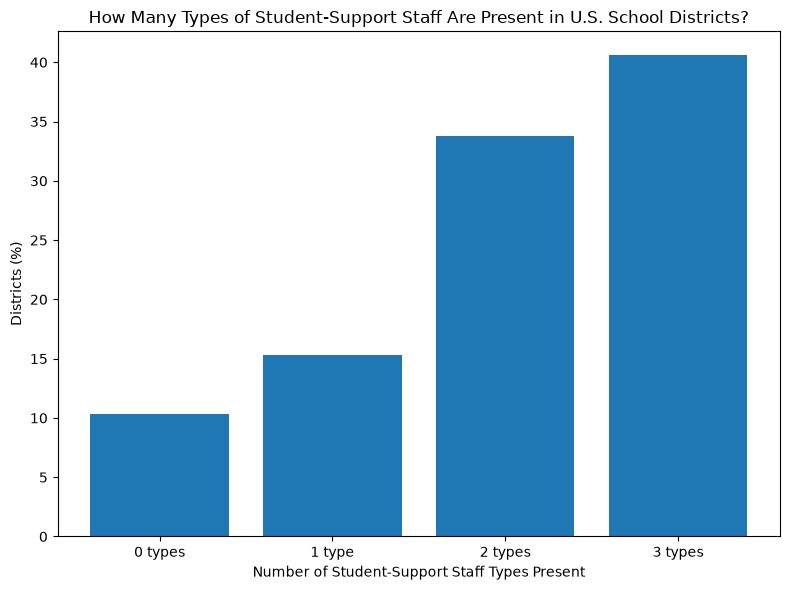

In [42]:
support_type_distribution = (
    staffing_50["SUPPORT_TYPES_PRESENT"]
    .value_counts()
    .sort_index()
)

support_type_pct = (
    support_type_distribution / support_type_distribution.sum() * 100
)

plt.figure(figsize=(8, 6))

plt.bar(
    ["0 types", "1 type", "2 types", "3 types"],
    support_type_pct.reindex([0, 1, 2, 3]).values
)

plt.xlabel("Number of Student-Support Staff Types Present")
plt.ylabel("Districts (%)")
plt.title(
    "How Many Types of Student-Support Staff Are Present in U.S. School Districts?"
)

plt.tight_layout()
plt.show()

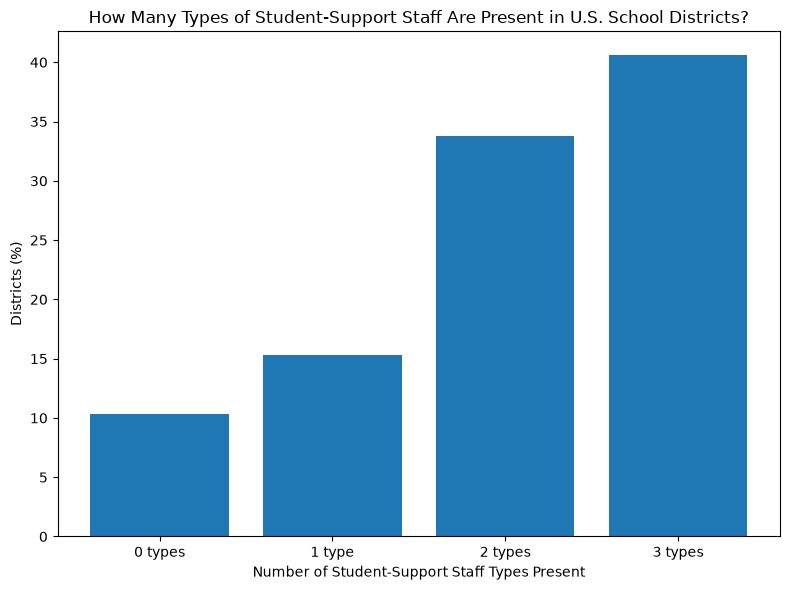

In [43]:
support_type_distribution = (
    staffing_50["SUPPORT_TYPES_PRESENT"]
    .value_counts()
    .sort_index()
)

support_type_pct = (
    support_type_distribution / support_type_distribution.sum() * 100
)

plt.figure(figsize=(8, 6))

plt.bar(
    ["0 types", "1 type", "2 types", "3 types"],
    support_type_pct.reindex([0, 1, 2, 3]).values
)

plt.xlabel("Number of Student-Support Staff Types Present")
plt.ylabel("Districts (%)")
plt.title(
    "How Many Types of Student-Support Staff Are Present in U.S. School Districts?"
)

plt.tight_layout()
plt.show()

In [44]:
state_support_breadth = (
    staffing_50
    .groupby("STATENAME")["SUPPORT_TYPES_PRESENT"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("PERCENT")
    .reset_index()
)

state_support_breadth_pivot = (
    state_support_breadth
    .pivot(
        index="STATENAME",
        columns="SUPPORT_TYPES_PRESENT",
        values="PERCENT"
    )
    .fillna(0)
)

state_support_breadth_pivot.columns = [
    f"{int(col)}_TYPES"
    for col in state_support_breadth_pivot.columns
]

state_support_breadth_pivot.head()

,0_TYPES,1_TYPES,2_TYPES,3_TYPES
STATENAME,,,,
ALABAMA,1.307190,2.614379,92.156863,3.921569
ALASKA,28.301887,30.188679,22.641509,18.867925
ARIZONA,37.784522,25.493171,20.637329,16.084977
ARKANSAS,0.380228,3.041825,79.847909,16.730038
CALIFORNIA,26.163968,17.611336,17.712551,38.512146


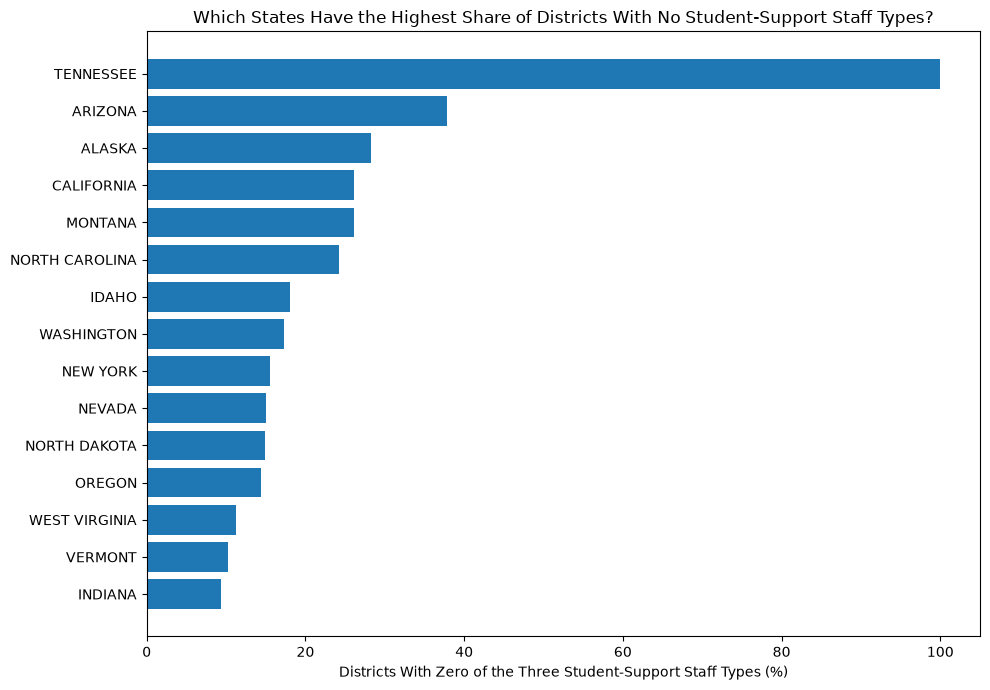

In [45]:
zero_support_types_states = (
    state_support_breadth_pivot
    .sort_values("0_TYPES", ascending=False)
    .head(15)
    .sort_values("0_TYPES")
)

plt.figure(figsize=(10, 7))

plt.barh(
    zero_support_types_states.index,
    zero_support_types_states["0_TYPES"]
)

plt.xlabel(
    "Districts With Zero of the Three Student-Support Staff Types (%)"
)
plt.ylabel("")
plt.title(
    "Which States Have the Highest Share of Districts With No Student-Support Staff Types?"
)

plt.tight_layout()
plt.show()

## Student Access to Multiple Support Roles

District staffing availability is also examined from the student perspective.

Each district is classified according to whether it reports positive staffing in three student-support categories:

- guidance counselors
- school psychologists
- broader student-support services staff

Districts are classified as having **0, 1, 2, or all 3 support-role types present**.

Student enrollment is then aggregated within these categories. This shows not only how many districts have different combinations of support roles, but how many students attend schools within those staffing environments.

This measure reflects the **breadth of reported support-role availability**, not the number of individual staff members or the quality of services provided.

In [46]:
staffing_50["HAS_GUIDANCE_COUNSELOR"] = (
    staffing_50["GUIDANCE_COUNSELORS"] > 0
).astype(int)

staffing_50["HAS_PSYCHOLOGIST"] = (
    staffing_50["SCHOOL_PSYCHOLOGISTS"] > 0
).astype(int)

staffing_50["HAS_SUPPORT_STAFF"] = (
    staffing_50["STUDENT_SUPPORT_STAFF"] > 0
).astype(int)

staffing_50["SUPPORT_TYPES_PRESENT"] = (
    staffing_50["HAS_GUIDANCE_COUNSELOR"]
    + staffing_50["HAS_PSYCHOLOGIST"]
    + staffing_50["HAS_SUPPORT_STAFF"]
)

staffing_50[
    ["LEA_NAME", "STATENAME", "TOTAL_ENROLLMENT", "SUPPORT_TYPES_PRESENT"]
].head()

,LEA_NAME,STATENAME,TOTAL_ENROLLMENT,SUPPORT_TYPES_PRESENT
1,Albertville City,ALABAMA,5910.0,2
2,Marshall County,ALABAMA,6494.0,2
3,Hoover City,ALABAMA,13632.0,2
4,Madison City,ALABAMA,13046.0,3
7,Leeds City,ALABAMA,2271.0,2


In [47]:
state_student_support_access = (
    staffing_50
    .dropna(subset=["TOTAL_ENROLLMENT"])
    .groupby(
        ["STATENAME", "SUPPORT_TYPES_PRESENT"],
        as_index=False
    )["TOTAL_ENROLLMENT"]
    .sum()
)

state_totals = (
    state_student_support_access
    .groupby("STATENAME")["TOTAL_ENROLLMENT"]
    .transform("sum")
)

state_student_support_access["STUDENT_PCT"] = (
    state_student_support_access["TOTAL_ENROLLMENT"]
    / state_totals
    * 100
)

state_student_support_access.head(10)

,STATENAME,SUPPORT_TYPES_PRESENT,TOTAL_ENROLLMENT,STUDENT_PCT
0,ALABAMA,0,757.0,0.100791
1,ALABAMA,1,8523.0,1.134796
2,ALABAMA,2,702123.0,93.484276
3,ALABAMA,3,39657.0,5.280137
4,ALASKA,0,3346.0,2.576304
5,ALASKA,1,7504.0,5.777819
6,ALASKA,2,24473.0,18.843358
7,ALASKA,3,94553.0,72.802519
8,ARIZONA,0,94770.0,8.594250
9,ARIZONA,1,61368.0,5.565178


In [48]:
student_access_pivot = (
    state_student_support_access
    .pivot(
        index="STATENAME",
        columns="SUPPORT_TYPES_PRESENT",
        values="STUDENT_PCT"
    )
    .fillna(0)
)

student_access_pivot = student_access_pivot.reindex(
    columns=[0, 1, 2, 3],
    fill_value=0
)

student_access_pivot.columns = [
    "0_ROLES",
    "1_ROLE",
    "2_ROLES",
    "3_ROLES"
]

student_access_pivot.round(1).head()

,0_ROLES,1_ROLE,2_ROLES,3_ROLES
STATENAME,,,,
ALABAMA,0.1,1.1,93.5,5.3
ALASKA,2.6,5.8,18.8,72.8
ARIZONA,8.6,5.6,14.0,71.8
ARKANSAS,0.0,1.8,47.3,50.8
CALIFORNIA,2.6,2.7,5.5,89.2


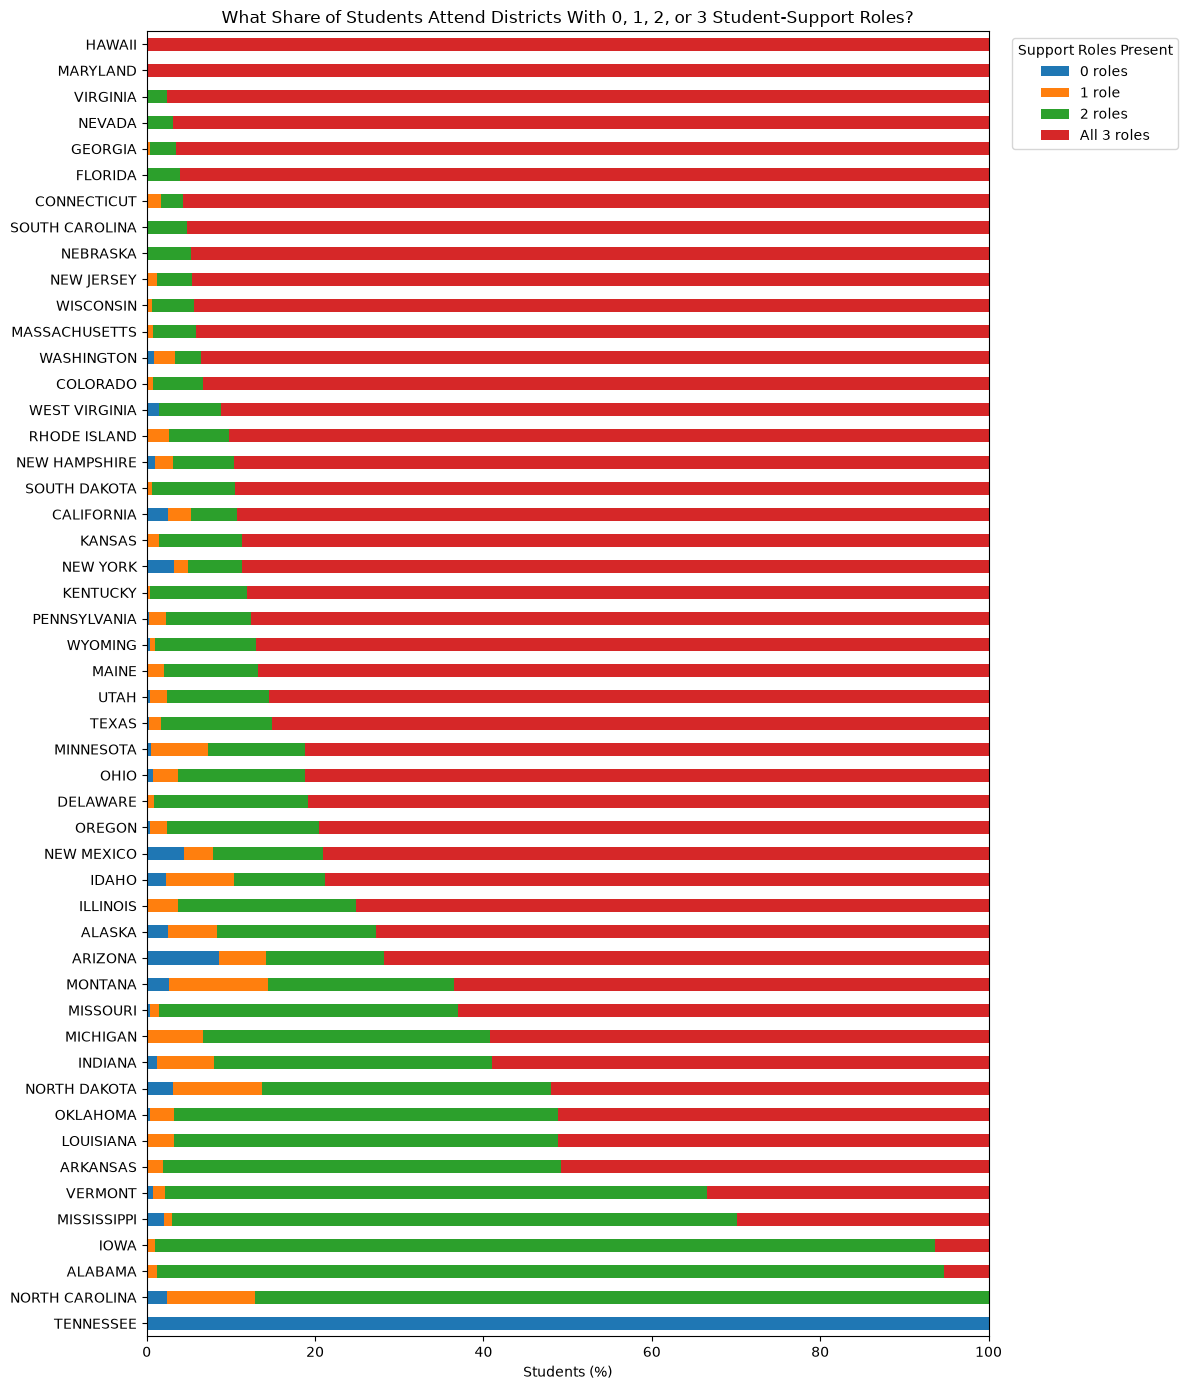

In [49]:
student_access_chart = (
    student_access_pivot
    .sort_values("3_ROLES", ascending=True)
)

ax = student_access_chart.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 14)
)

plt.xlabel("Students (%)")
plt.ylabel("")
plt.title(
    "What Share of Students Attend Districts With 0, 1, 2, or 3 Student-Support Roles?"
)

plt.legend(
    [
        "0 roles",
        "1 role",
        "2 roles",
        "All 3 roles"
    ],
    title="Support Roles Present",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

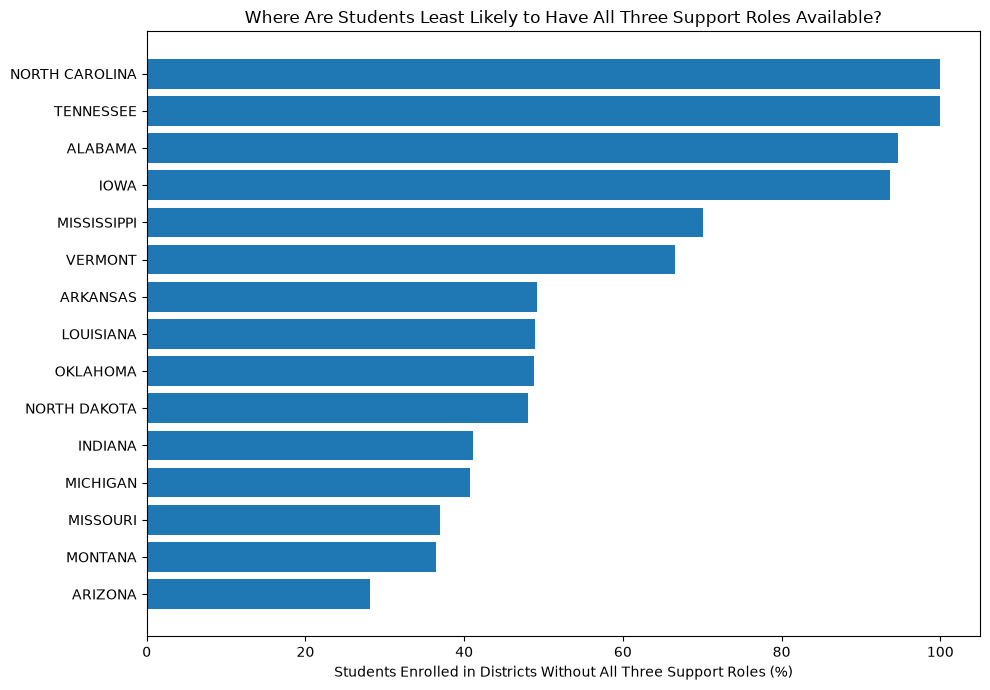

In [50]:
students_without_all_three = (
    student_access_pivot
    .assign(
        LESS_THAN_3_ROLES=lambda x:
        x["0_ROLES"] + x["1_ROLE"] + x["2_ROLES"]
    )
    .sort_values("LESS_THAN_3_ROLES", ascending=False)
    .head(15)
    .sort_values("LESS_THAN_3_ROLES")
)

plt.figure(figsize=(10, 7))

plt.barh(
    students_without_all_three.index,
    students_without_all_three["LESS_THAN_3_ROLES"]
)

plt.xlabel(
    "Students Enrolled in Districts Without All Three Support Roles (%)"
)
plt.ylabel("")

plt.title(
    "Where Are Students Least Likely to Have All Three Support Roles Available?"
)

plt.tight_layout()
plt.show()

## Specific Student-Support Role Combinations

The number of support-role types present does not identify which specific roles are available.

Districts with one support role may have a counselor, psychologist, or broader student-support staff member. Districts with two roles may also have different combinations.

To distinguish these staffing environments, districts are classified into eight possible combinations of the three support roles.

In [51]:
def support_combination(row):
    roles = []

    if row["HAS_GUIDANCE_COUNSELOR"] == 1:
        roles.append("Counselor")

    if row["HAS_PSYCHOLOGIST"] == 1:
        roles.append("Psychologist")

    if row["HAS_SUPPORT_STAFF"] == 1:
        roles.append("Support Staff")

    if len(roles) == 0:
        return "None"

    return " + ".join(roles)


staffing_50["SUPPORT_ROLE_COMBINATION"] = staffing_50.apply(
    support_combination,
    axis=1
)

staffing_50["SUPPORT_ROLE_COMBINATION"].value_counts()

SUPPORT_ROLE_COMBINATION
Counselor + Psychologist + Support Staff    7207
Counselor + Support Staff                   4920
None                                        1836
Support Staff                               1597
Counselor                                   1029
Psychologist + Support Staff                 724
Counselor + Psychologist                     353
Psychologist                                  94
Name: count, dtype: int64

In [52]:
student_combination_access = (
    staffing_50
    .dropna(subset=["TOTAL_ENROLLMENT"])
    .groupby(
        ["STATENAME", "SUPPORT_ROLE_COMBINATION"],
        as_index=False
    )["TOTAL_ENROLLMENT"]
    .sum()
)

state_enrollment_total = (
    student_combination_access
    .groupby("STATENAME")["TOTAL_ENROLLMENT"]
    .transform("sum")
)

student_combination_access["STUDENT_PCT"] = (
    student_combination_access["TOTAL_ENROLLMENT"]
    / state_enrollment_total
    * 100
)

student_combination_access.head()

,STATENAME,SUPPORT_ROLE_COMBINATION,TOTAL_ENROLLMENT,STUDENT_PCT
0,ALABAMA,Counselor,7950.0,1.058504
1,ALABAMA,Counselor + Psychologist + Support Staff,39657.0,5.280137
2,ALABAMA,Counselor + Support Staff,702123.0,93.484276
3,ALABAMA,None,757.0,0.100791
4,ALABAMA,Support Staff,573.0,0.076292


In [53]:
combination_pivot = (
    student_combination_access
    .pivot(
        index="STATENAME",
        columns="SUPPORT_ROLE_COMBINATION",
        values="STUDENT_PCT"
    )
    .fillna(0)
)

combination_pivot.round(1)

SUPPORT_ROLE_COMBINATION,Counselor,Counselor + Psychologist,Counselor + Psychologist + Support Staff,Counselor + Support Staff,None,Psychologist,Psychologist + Support Staff,Support Staff
STATENAME,,,,,,,,
ALABAMA,1.1,0.0,5.3,93.5,0.1,0.0,0.0,0.1
ALASKA,5.0,0.3,72.8,18.6,2.6,0.0,0.0,0.8
ARIZONA,0.6,0.0,71.8,9.7,8.6,0.0,4.3,5.0
ARKANSAS,1.1,0.0,50.8,47.2,0.0,0.0,0.1,0.8
CALIFORNIA,1.9,2.3,89.2,0.9,2.6,0.5,2.2,0.3
COLORADO,0.2,0.0,93.3,5.9,0.1,0.0,0.0,0.5
CONNECTICUT,0.0,0.0,95.6,1.4,0.0,0.0,1.2,1.7
DELAWARE,0.0,0.0,80.8,17.8,0.0,0.0,0.5,0.9
FLORIDA,0.0,0.0,96.0,3.9,0.0,0.0,0.1,0.0


## Student Access by Specific Support-Role Combination

The previous analysis counted how many support-role types were present. This analysis identifies the specific combination of roles available to students.

Each state's bar represents 100% of students and is divided according to the staffing combination reported by their district.

This makes it possible to distinguish, for example, students in districts with two roles consisting of counselor + psychologist from students in districts with counselor + broader support staff.

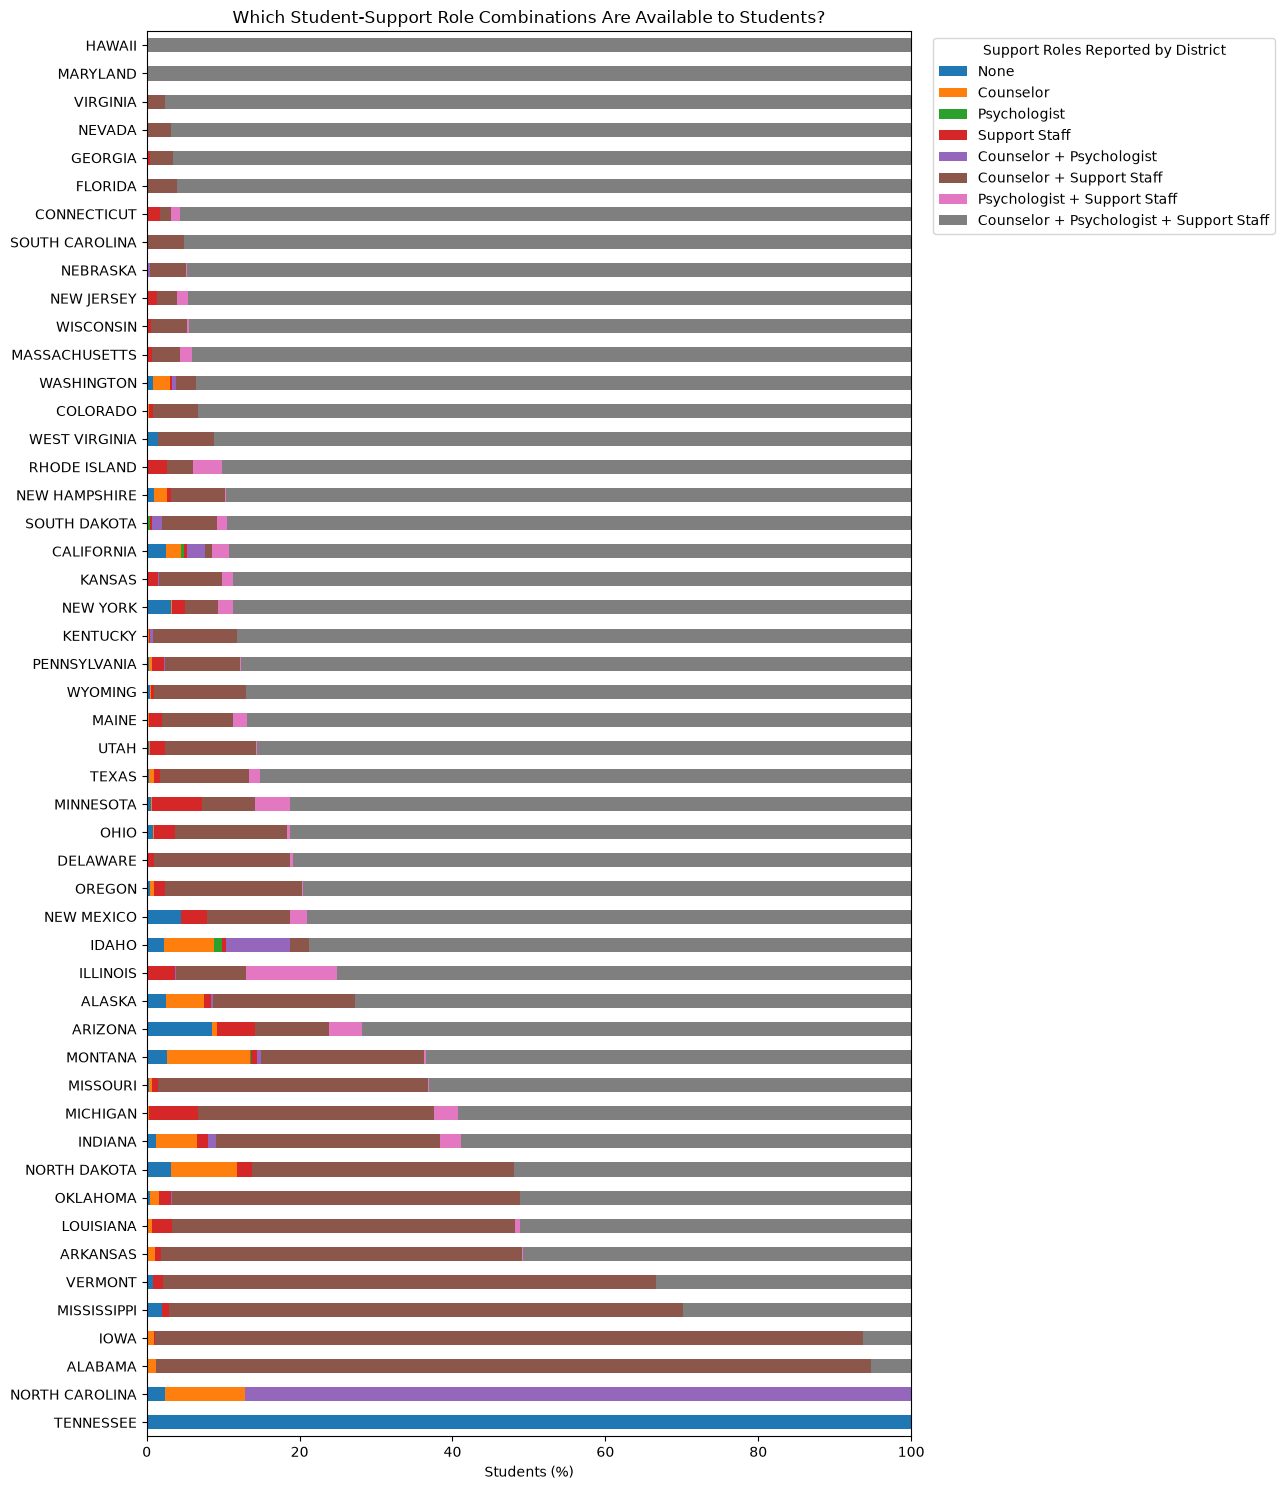

In [54]:
# Put combinations in a logical order

combination_order = [
    "None",
    "Counselor",
    "Psychologist",
    "Support Staff",
    "Counselor + Psychologist",
    "Counselor + Support Staff",
    "Psychologist + Support Staff",
    "Counselor + Psychologist + Support Staff"
]

# Make sure every possible combination exists as a column
combination_chart = combination_pivot.reindex(
    columns=combination_order,
    fill_value=0
)

# Sort states by percentage of students with all 3 roles
combination_chart = combination_chart.sort_values(
    "Counselor + Psychologist + Support Staff",
    ascending=True
)

ax = combination_chart.plot(
    kind="barh",
    stacked=True,
    figsize=(13, 15)
)

plt.xlabel("Students (%)")
plt.ylabel("")

plt.title(
    "Which Student-Support Role Combinations Are Available to Students?"
)

plt.legend(
    title="Support Roles Reported by District",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

## Statistical Relationships Among District Staffing Measures

Correlation analysis is used to examine whether different student-support staffing measures tend to vary together across school districts.

The analysis focuses on:

- students per guidance counselor
- students per school psychologist
- students per broader student-support staff member
- students per teacher
- district enrollment

Higher student-to-staff ratios indicate lower staffing capacity.

In [55]:
nonfiscal_corr_vars = [
    "TOTAL_ENROLLMENT",
    "STUDENTS_PER_GUIDANCE_COUNSELOR",
    "STUDENTS_PER_PSYCHOLOGIST",
    "STUDENTS_PER_SUPPORT_STAFF",
    "STUDENTS_PER_TEACHER"
]

nonfiscal_correlations = (
    district_staffing[nonfiscal_corr_vars]
    .corr()
    .round(2)
)

nonfiscal_correlations

,TOTAL_ENROLLMENT,STUDENTS_PER_GUIDANCE_COUNSELOR,STUDENTS_PER_PSYCHOLOGIST,STUDENTS_PER_SUPPORT_STAFF,STUDENTS_PER_TEACHER
TOTAL_ENROLLMENT,1.00,-0.00,0.06,0.00,0.02
STUDENTS_PER_GUIDANCE_COUNSELOR,-0.00,1.00,0.06,0.02,0.05
STUDENTS_PER_PSYCHOLOGIST,0.06,0.06,1.00,0.03,0.04
STUDENTS_PER_SUPPORT_STAFF,0.00,0.02,0.03,1.00,0.13
STUDENTS_PER_TEACHER,0.02,0.05,0.04,0.13,1.00


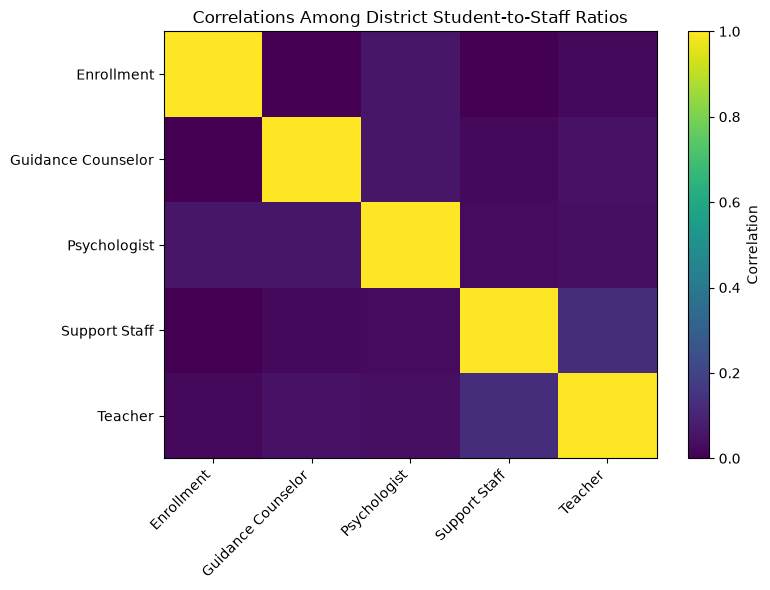

In [56]:
plt.figure(figsize=(8, 6))

plt.imshow(
    nonfiscal_correlations,
    aspect="auto"
)

plt.colorbar(label="Correlation")

labels = [
    "Enrollment",
    "Guidance Counselor",
    "Psychologist",
    "Support Staff",
    "Teacher"
]

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title(
    "Correlations Among District Student-to-Staff Ratios"
)

plt.tight_layout()
plt.show()

In [57]:
import nbformat
from pathlib import Path
from copy import deepcopy

source_path = Path("04_nces_nonfiscal_data_analysis.ipynb")
final_path = Path("../Final_Data_Analysis/07_full_project_analysis.ipynb")

# Load notebooks
with open(source_path, "r", encoding="utf-8") as f:
    source_nb = nbformat.read(f, as_version=4)

with open(final_path, "r", encoding="utf-8") as f:
    final_nb = nbformat.read(f, as_version=4)

# Find the NCES Nonfiscal section in the final notebook
start_idx = None
end_idx = None

for i, cell in enumerate(final_nb.cells):
    if cell.cell_type == "markdown":
        text = cell.source.lower()

        if "nces nonfiscal" in text or "nces non-fiscal" in text:
            start_idx = i
            break

if start_idx is None:
    raise ValueError("Could not find the NCES Nonfiscal section in the final notebook.")

# Find the next major dataset section
for i in range(start_idx + 1, len(final_nb.cells)):
    cell = final_nb.cells[i]

    if cell.cell_type == "markdown" and cell.source.startswith("# "):
        end_idx = i
        break

if end_idx is None:
    end_idx = len(final_nb.cells)

# Copy the completed Nonfiscal notebook cells
new_cells = [deepcopy(cell) for cell in source_nb.cells]

# Replace the placeholder section
final_nb.cells[start_idx:end_idx] = new_cells

# Save
with open(final_path, "w", encoding="utf-8") as f:
    nbformat.write(final_nb, f)

print("NCES Nonfiscal cells inserted:", len(new_cells))
print("Saved final notebook:", final_path)

NCES Nonfiscal cells inserted: 59
Saved final notebook: ..\Final_Data_Analysis\07_full_project_analysis.ipynb
